In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch03. 비지도학습 군집분석</font>

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(160, 195)

171

In [4]:
data = []
for i in range(50):
    # 여자 데이터 (키와 몸무게) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터 (키와 몸무게) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [11]:
print('여자 몸무게 (x축) : ',[female[0] for female in data[::2]])
print('여자 몸무게 (y축) : ',[female[1] for female in data[::2]])

여자 몸무게 (x축) :  [69, 52, 42, 68, 70, 65, 49, 64, 40, 66, 60, 70, 69, 55, 52, 66, 61, 63, 46, 45, 67, 41, 40, 40, 61, 46, 53, 66, 48, 56, 42, 54, 62, 63, 55, 66, 69, 51, 44, 42, 63, 47, 55, 59, 53, 47, 55, 53, 58, 70]
여자 몸무게 (y축) :  [155, 145, 141, 164, 170, 164, 166, 153, 143, 164, 143, 155, 145, 143, 143, 161, 164, 153, 168, 147, 164, 154, 150, 165, 153, 145, 165, 145, 146, 154, 158, 144, 165, 153, 159, 153, 144, 168, 141, 149, 163, 148, 151, 142, 165, 157, 149, 167, 170, 168]


In [12]:
print('남자 몸무게 (x축) : ',[male[0] for male in data[1::2]])
print('남자 몸무게 (y축) : ',[male[1] for male in data[1::2]])

남자 몸무게 (x축) :  [81, 92, 70, 91, 80, 94, 60, 87, 76, 90, 94, 63, 73, 87, 63, 82, 73, 75, 85, 93, 60, 60, 83, 76, 74, 88, 90, 75, 64, 69, 72, 64, 82, 82, 86, 69, 95, 83, 94, 61, 68, 60, 60, 63, 94, 80, 70, 73, 85, 74]
남자 몸무게 (y축) :  [177, 165, 166, 190, 177, 188, 166, 177, 162, 190, 181, 191, 170, 187, 180, 191, 185, 190, 194, 183, 191, 190, 164, 163, 174, 171, 168, 172, 185, 168, 165, 162, 173, 176, 188, 175, 170, 173, 179, 188, 166, 191, 184, 170, 185, 181, 195, 185, 186, 172]


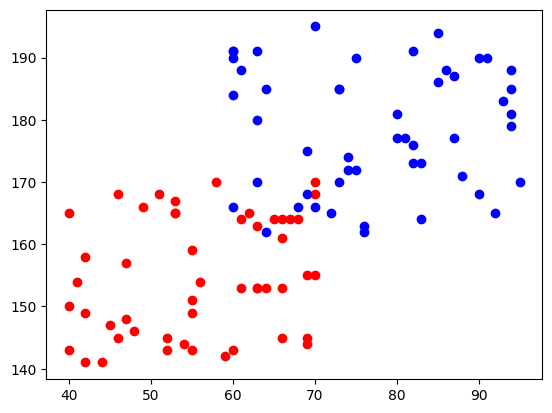

In [16]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color = 'r')
plt.plot([male[0] for male in data[1::2]],
         [male[1] for male in data[1::2]], 'o', color = 'b')
plt.show()

# 2. 군집화 로직

In [102]:
# 초기 랜덤 지정 2 point
random_points = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_points

[[56, 146], [79, 179]]

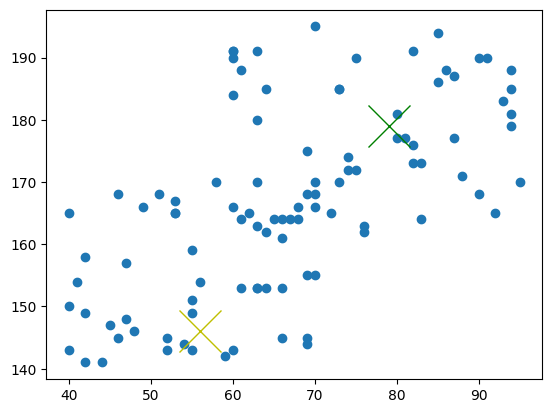

In [104]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_points[0][0],random_points[0][1], 'x', markersize=30, color='y')
plt.plot(random_points[1][0],random_points[1][1], 'x', markersize=30, color='g')
plt.show()

In [111]:
# 두 점 거리를 return하는 함수
def dist(a, b):
    return np.sqrt((a[0]-b[0])**2+(a[1]-b[1])**2)

In [113]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)으로 분류
group0=[]
group1=[]
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(46, 54)

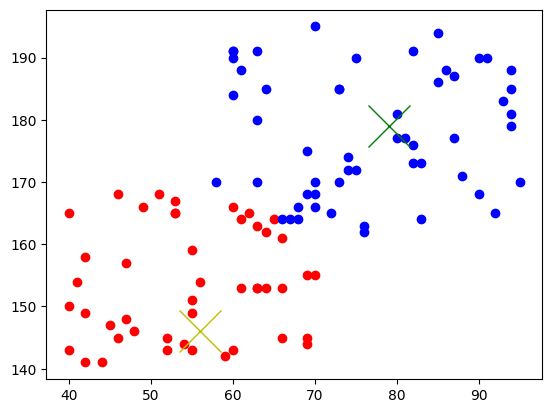

In [117]:
# group0, group1
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='r')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='b')
plt.plot(random_points[0][0],random_points[0][1], 'x', markersize=30, color='y')
plt.plot(random_points[1][0],random_points[1][1], 'x', markersize=30, color='g')

In [118]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group0])
group1_meanY = np.mean([d[1] for d in group0])
random_points[1] = [group0_meanX, group0_meanY]

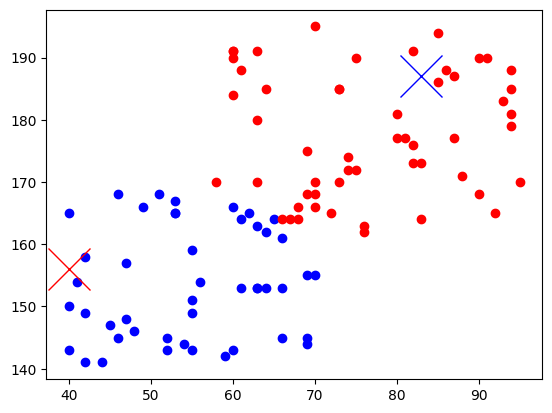

In [119]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()